# 03 — Robustness: bootstrap intervals, sub-periods, sensitivity (SPY)

Loads the outputs of `experiments/run_robustness.py configs/comparison_spy.yaml`. The question is not *which point estimate is higher* but *which differences survive resampling, era changes, and parameter perturbations*.

In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from regimelab import plotting

FIG = ROOT / "reports" / "figures"
OUT = ROOT / "experiments" / "outputs" / "comparison_spy"
boot = pd.read_csv(OUT / "bootstrap_sharpe_diffs.csv", index_col=0)
sens = pd.read_csv(OUT / "vol_gate_sensitivity.csv")
sub = pd.read_csv(OUT / "subperiod_metrics.csv")
boot[["diff", "ci_low", "ci_high", "prob_nonpositive"]].round(3)

,diff,ci_low,ci_high,prob_nonpositive
comparison,,,,
vol20q80_bh vs buy_and_hold,0.175,-0.119,0.497,0.138
hmm2_bh vs buy_and_hold,0.169,-0.155,0.523,0.186
hmm2p_bh vs buy_and_hold,0.160,-0.144,0.497,0.180
hmm3_bh vs buy_and_hold,0.003,-0.145,0.172,0.525
vol20q80_trend vs trend_200d,0.048,-0.094,0.208,0.284
hmm2_trend vs trend_200d,0.058,-0.167,0.288,0.312
hmm3_trend vs trend_200d,0.003,-0.055,0.072,0.498
vol20q80_bh vs hmm2_bh,0.006,-0.216,0.222,0.489
vol20q80_bh vs hmm2p_bh,0.015,-0.184,0.205,0.438


PosixPath('/Users/mohamedryad/Desktop/RegimeLab/reports/figures/spy_bootstrap.png')

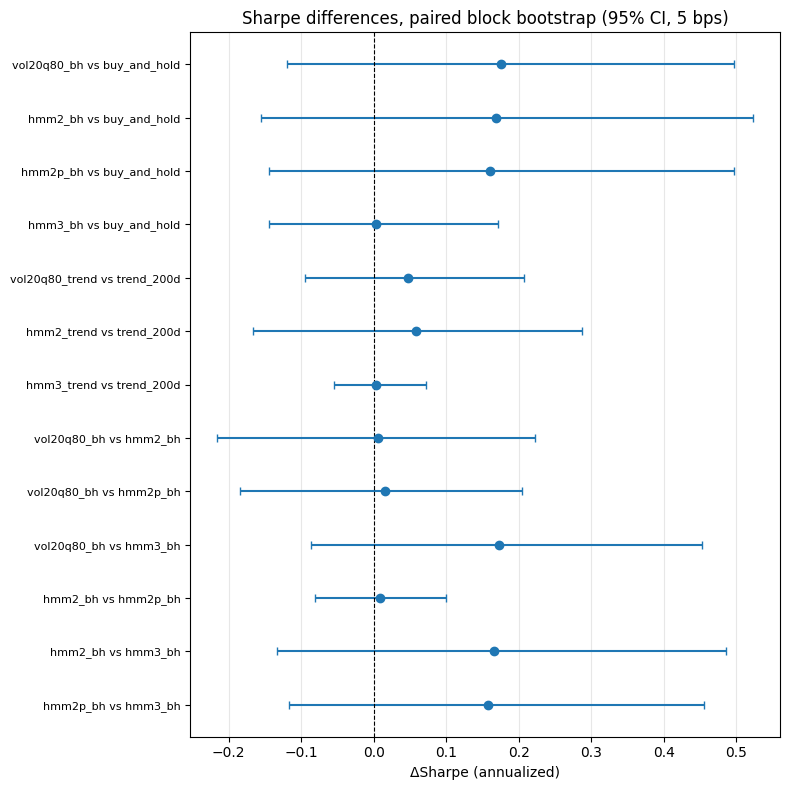

In [2]:
fig = plotting.bootstrap_forest(boot, title="Sharpe differences, paired block bootstrap (95% CI, 5 bps)")
plotting.save_figure(fig, FIG / "spy_bootstrap.png")

PosixPath('/Users/mohamedryad/Desktop/RegimeLab/reports/figures/spy_sensitivity.png')

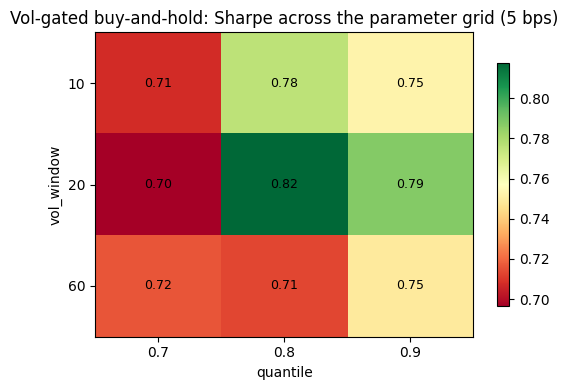

In [3]:
pivot = sens.pivot(index="vol_window", columns="quantile", values="sharpe")
fig = plotting.sensitivity_heatmap(pivot, title="Vol-gated buy-and-hold: Sharpe across the parameter grid (5 bps)")
plotting.save_figure(fig, FIG / "spy_sensitivity.png")

PosixPath('/Users/mohamedryad/Desktop/RegimeLab/reports/figures/spy_subperiods.png')

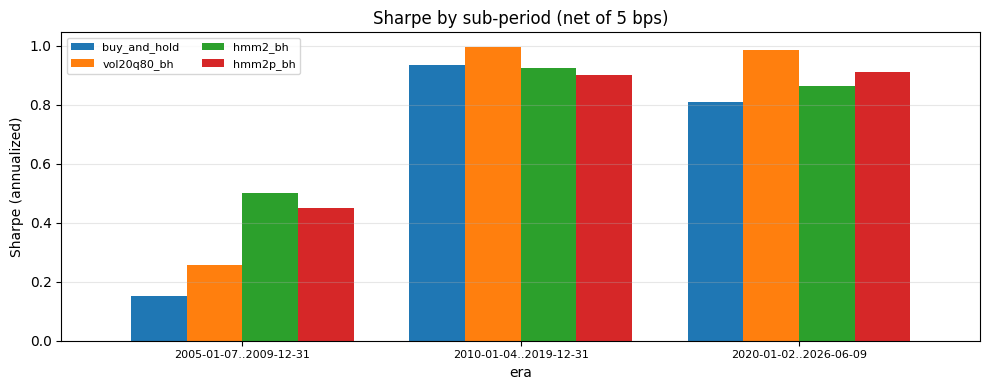

In [4]:
sharpe = sub.pivot(index="era", columns="strategy", values="sharpe")
cols = ["buy_and_hold", "vol20q80_bh", "hmm2_bh", "hmm2p_bh"]
fig = plotting.subperiod_bars(sharpe[cols], title="Sharpe by sub-period (net of 5 bps)")
plotting.save_figure(fig, FIG / "spy_subperiods.png")

**Reading.** Every 95% interval on a Sharpe difference includes zero: 21 years of daily data cannot certify a ~+0.17 Sharpe improvement. The sub-period bars show the Sharpe edge lives in 2005–09 (and 2020+ for the vol gate), while drawdown reduction (see `subperiod_metrics.csv`) appears in *every* era. The sensitivity grid is a plateau — all cells beat buy-and-hold's 0.64 — so the vol gate is not a tuned artifact.